# Буткемп, день 7 — возврат к среднему: OU, half-life и цена ошибки

Вчера мы выяснили, что cross-venue спред перпетуалов BTC при $\beta = 1$ стационарен: ADF отвергает единичный корень, а half-life по AR(1) на 1-с сетке — около шести секунд. Это ответ на вопрос «возвращается ли спред». День 7 спрашивает другое: **как быстро, как далеко и какова цена ошибки**. Как быстро — это half-life процесса Орнштейна–Уленбека (OU) и то, насколько честно мы его оценили. Как далеко — это равновесное стандартное отклонение спреда (equilibrium sd), то есть типичная амплитуда отклонения. Цена ошибки — это round-trip издержки, которые платит любой вход и выход. Задание дня — шесть пунктов: фит OU и bootstrap его half-life; point-in-time band-стратегию с честным учётом издержек; показ того, насколько льстит бэктесту centred mean; сравнение equilibrium sd с ценой круговой сделки; симуляционное сравнение rolling OLS и Kalman для динамического hedge ratio; и, наконец, словесный разбор funding. Ниже мы идём по этим пунктам, и там, где результат неудобный, говорим прямо.

## Что дано

| файл | содержимое | каденс | период |
|---|---|---|---|
| [`l2_executable_quotes_100ms_10000.parquet`](../Downloads/l2_executable_quotes_100ms_10000.parquet) | top-of-book трёх бирж, BTC и ETH | 100 мс | 2026-07-01 03:00 .. 07-03 03:00 MSK (48 ч) |

Гребёнки 1 с и 5 с мы строим сами из 100-мс котировок тем же приёмом, что на дне 6: метка $t$ получает последнюю котировку **не позже** $t$ (`merge_asof(direction='backward')`, эквивалентно `dt.floor(rule)` + `groupby.last()`), короткие дыры после джойна закрываются `ffill(limit=5)` — тянем не больше пяти тактов, длиннее остаются пропусками, а не выдуманными числами. Из трёх бирж и двух активов нам в этом дне нужен один объект: **cross-venue спред BTC при $\beta = 1$**. Почему именно $\beta = 1$: один и тот же инструмент (перпетуал BTC) на разных площадках — это, с точностью до валюты маржи, одна бумага, поэтому хеджевое отношение равно единице **по смыслу задачи**, а не оценивается. Спред держим в базисных пунктах:

$$s = \frac{P_A - P_B}{\mathrm{mid}} \cdot 10^4, \qquad \mathrm{mid} = \frac{P_A + P_B}{2}.$$

Базисные пункты здесь не украшение: equilibrium sd спреда и издержки торговли живут в одних и тех же единицах, и их отношение — главный вопрос дня. Три биржи дают три пары: Bybit–Okex, Bybit–Binance, Okex–Binance.

В выдаче только L2-котировки перпетуалов — нет funding-ставок, нет spot-ноги и нет датированных контрактов, поэтому funding-составляющую мы обсуждаем только концептуально (пункт 6) и нигде не подставляем выдуманных чисел.

Начинаем с окружения и констант. Про генератор случайных чисел: он зафиксирован, потому что bootstrap и Kalman-симуляция должны воспроизводиться при повторном прогоне. Счётчик испытаний ведём потому, что множественные сравнения — источник ложных находок; считаем при этом прогоны модели, а не внутренние шаги фильтра.

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import duckdb
import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import InterpolationWarning
from scipy.signal import lfilter
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=InterpolationWarning)
pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.figsize': (11, 4), 'axes.grid': True, 'grid.alpha': 0.3})
RNG = np.random.default_rng(7)          # фиксируем: bootstrap и симуляция должны воспроизводиться
TEST_COUNTER = {'AR(1)/OLS (фит OU)': 0, 'bootstrap-реплика': 0,
                'rolling OLS': 0, 'Kalman': 0, 'прогон стратегии': 0}

F100 = os.path.expanduser('~/Downloads/l2_executable_quotes_100ms_10000.parquet')
VENUES = ['Bybit', 'Okex', 'Binance']
PAIRS = [('Bybit', 'Okex'), ('Bybit', 'Binance'), ('Okex', 'Binance')]
GRIDS = {'1 s': ('1s', 1), '5 s': ('5s', 5)}
print('duckdb', duckdb.__version__, '| pandas', pd.__version__, '| numpy', np.__version__,
      '| statsmodels', sm.__version__)


duckdb 1.5.6 | pandas 3.0.6 | numpy 2.5.3 | statsmodels 0.15.0


## Разведка данных

Прежде чем что-то считать, убеждаемся, что схема совпадает с днём 6, а на коротком окне видно ожидаемое: три биржи, два актива, покрытие почти полное. Полную сборку сеток делаем один раз и кэшируем в `/tmp/hw7_mid_*.parquet` — пересобирать 10 млн строк на каждом прогоне незачем, а сам сборщик идемпотентен: если кэш есть, остаётся только чтение.

In [2]:
con = duckdb.connect()
schema = con.execute("DESCRIBE SELECT * FROM read_parquet(?)", [F100]).df()
print('=== схема файла ===')
display(schema[['column_name', 'column_type']])
cov = con.execute("""
    SELECT exchange, asset, count(*) AS n, min(event_time) AS t0, max(event_time) AS t1
    FROM read_parquet(?) WHERE mid IS NOT NULL GROUP BY 1, 2 ORDER BY 1, 2
""", [F100]).df()
print('=== строки по биржам и активам ===')
display(cov)


=== схема файла ===


,column_name,column_type
0,event_time,TIMESTAMP WITH TIME ZONE
1,exchange,VARCHAR
2,asset,VARCHAR
3,best_bid,DOUBLE
4,best_ask,DOUBLE
5,best_bid_amount,DOUBLE
6,best_ask_amount,DOUBLE
7,sell_vwap,DOUBLE
8,buy_vwap,DOUBLE
9,mid,DOUBLE


=== строки по биржам и активам ===


,exchange,asset,n,t0,t1
0,Binance,BTC,1727372,2026-07-01 03:00:00.099138+03:00,2026-07-03 02:59:59.885058+03:00
1,Binance,ETH,1727417,2026-07-01 03:00:00.097052+03:00,2026-07-03 02:59:59.884493+03:00
2,Bybit,BTC,1674680,2026-07-01 03:00:00.083350+03:00,2026-07-03 02:59:59.896158+03:00
3,Bybit,ETH,1670735,2026-07-01 03:00:00.093596+03:00,2026-07-03 02:59:59.885056+03:00
4,Okex,BTC,1718823,2026-07-01 03:00:00.096092+03:00,2026-07-03 02:59:59.884409+03:00
5,Okex,ETH,1725952,2026-07-01 03:00:00.089859+03:00,2026-07-03 02:59:59.892235+03:00


In [3]:
def build_grid(rule):
    """Полная сетка mid: floor(rule) + last, затем ffill(limit=5). Кэш в /tmp."""
    cache = f'/tmp/hw7_mid_{rule}.parquet'
    if os.path.exists(cache):
        return pd.read_parquet(cache)
    df = con.execute("""
        SELECT event_time, exchange, asset, mid FROM read_parquet(?)
        WHERE mid IS NOT NULL ORDER BY event_time
    """, [F100]).df()
    df['event_time'] = pd.to_datetime(df['event_time'], utc=True)
    df['t'] = df['event_time'].dt.floor(rule)
    g = (df.groupby(['t', 'exchange', 'asset'])['mid'].last()
           .unstack(['exchange', 'asset']).ffill(limit=5))
    g.to_parquet(cache)
    return g

MID = {}
t0 = time.time()
for label, (rule, dt) in GRIDS.items():
    MID[label] = build_grid(rule)
    gaps = int(MID[label].isna().sum().sum())
    print(f'{label}: тактов {len(MID[label]):>7}, колонок {MID[label].shape[1]}, '
          f'пропусков {gaps}  ({time.time() - t0:.1f} с)')
print('индекс:', MID['1 s'].index[0], '..', MID['1 s'].index[-1])


1 s: тактов  172800, колонок 6, пропусков 280  (0.1 с)
5 s: тактов   34560, колонок 6, пропусков 35  (0.2 с)
индекс: 2026-07-01 03:00:00+03:00 .. 2026-07-03 02:59:59+03:00


In [4]:
def spread_bps(g, a, b, asset='BTC'):
    """Cross-venue спред в bps: (P_A - P_B) / mid * 1e4."""
    pa, pb = g[(a, asset)], g[(b, asset)]
    return ((pa - pb) / ((pa + pb) / 2) * 1e4).dropna()

print('=== короткое окно: 1-с спред Bybit-Okex, первые 5 минут ===')
head = spread_bps(MID['1 s'], 'Bybit', 'Okex').iloc[:300]
display(head.describe().round(4).to_frame('bps'))


=== короткое окно: 1-с спред Bybit-Okex, первые 5 минут ===


,bps
count,300.0000
mean,0.1722
std,0.4504
min,-1.0905
25%,-0.1535
50%,0.1534
75%,0.5625
max,1.3628


## Гипотеза

Рабочая гипотеза дня: cross-venue спред BTC ведёт себя как процесс Орнштейна–Уленбека

$$dX = \kappa(\mu - X)\,dt + \sigma\,dW,$$

то есть возвращается к уровню $\mu$ со скоростью $\kappa$. Его наблюдаемые характеристики — half-life $\ln 2 / \kappa$ (сколько ждать, пока половина отклонения исчезнет) и equilibrium sd $\sigma / \sqrt{2\kappa}$ (типичная амплитуда отклонения в стационарном режиме). Проверяем два утверждения. Первое: half-life спреда — секунды, а не минуты, то есть спред возвращается быстрее, чем истекает терпение. Второе, и оно важнее: **выживает ли band-стратегия на этом возврате после издержек**. Интуиция подсказывает ответ заранее, и это нормально: если типичное отклонение — доли базисного пункта, а круговая сделка стоит несколько базисных пунктов, то честный итог — null, и его надо подать как результат, а не переиграть параметрами.

## Пункт 1 — фит OU-модели, half-life и её bootstrap

Дискретизация OU на шаге $\Delta$ — это AR(1):

$$s_t = a + \phi\,s_{t-1} + \varepsilon_t, \qquad \phi = e^{-\kappa\Delta}, \qquad \mu = \frac{a}{1-\phi}, \qquad \sigma_{eq}^2 = \frac{\mathrm{var}(\varepsilon)}{1-\phi^2}.$$

Оцениваем её регрессией приращения на уровень: $\Delta s = a + b\,s_{t-1} + e$. Это в точности ADF-регрессия с нулём лагов, поэтому $\phi = 1 + b$, $\kappa = -\ln\phi / \Delta$, а half-life в шагах равна $\ln 0.5 / \ln\phi$; чтобы получить секунды, умножаем на $\Delta$. Формула осмысленна только при $0 < \phi < 1$: если оценка вышла за единицу, выборка **не отличает спред от случайного блуждания**, и такую пару надо отметить, а не подставлять в формулу.

In [5]:
def ou_fit(s, dt):
    """Оценка OU через AR(1): Δs = a + b·s_{t-1} + e; φ=1+b; κ=−lnφ/Δt; half-life=ln2/κ;
    μ=a/(1−φ); σ_eq²=var(e)/(1−φ²). При φ вне (0,1) возвращаем NaN с явной пометкой."""
    s = np.asarray(pd.Series(s).dropna(), float)
    d = np.diff(s)
    fit = sm.OLS(d, sm.add_constant(s[:-1])).fit()
    a, b = fit.params
    phi = 1.0 + b
    TEST_COUNTER['AR(1)/OLS (фит OU)'] += 1
    if not 0.0 < phi < 1.0:
        return dict(phi=phi, kappa=np.nan, hl=np.nan, hl_steps=np.nan, mu=np.nan,
                    se=np.nan, eq=np.nan, n=len(s), a=a)
    kappa = -np.log(phi) / dt
    se = np.std(fit.resid, ddof=2)
    return dict(phi=phi, kappa=kappa, hl=np.log(2) / kappa, hl_steps=np.log(0.5) / np.log(phi),
                mu=a / (1 - phi), se=se, eq=np.sqrt(se**2 / (1 - phi**2)), n=len(s), a=a)

rows = []
OU = {}
for label, (rule, dt) in GRIDS.items():
    for a, b in PAIRS:
        s = spread_bps(MID[label], a, b)
        r = ou_fit(s, dt)
        OU[(label, a, b)] = (s, r)
        rows.append({'каденс': label, 'пара': f'{a}-{b}', 'n': r['n'], 'φ': round(r['phi'], 5),
                     'κ, 1/с': round(r['kappa'], 5), 'half-life, с': round(r['hl'], 2),
                     'half-life, тактов': round(r['hl_steps'], 2),
                     'μ, bps': round(r['mu'], 4), 'σ_eq, bps': round(r['eq'], 4)})
print('=== OU-фит cross-venue спреда BTC (β=1), 1 с и 5 с ===')
display(pd.DataFrame(rows))


=== OU-фит cross-venue спреда BTC (β=1), 1 с и 5 с ===


,каденс,пара,n,φ,"κ, 1/с","half-life, с","half-life, тактов","μ, bps","σ_eq, bps"
0,1 s,Bybit-Okex,172659,0.88804,0.11873,5.84,5.84,0.1689,0.8291
1,1 s,Bybit-Binance,172672,0.90010,0.10525,6.59,6.59,0.1862,0.8436
2,1 s,Okex-Binance,172775,0.89183,0.11448,6.05,6.05,0.0176,0.8394
3,5 s,Bybit-Okex,34541,0.80176,0.04419,15.69,3.14,0.1671,0.8280
4,5 s,Bybit-Binance,34541,0.83660,0.03568,19.43,3.89,0.1869,0.8467
5,5 s,Okex-Binance,34560,0.80223,0.04407,15.73,3.15,0.0202,0.8403


Читаем таблицу по смыслу. На 1-с сетке half-life лежит в диапазоне $5.8$–$6.6$ с: возврат действительно быстрый, но не мгновенный — это десятки тактов, а не один. На 5-с сетке та же величина выходит $15.7$–$19.4$ с, то есть в секундах **больше**, хотя в тактах — всего $3.1$–$3.9$. Расхождения нет: $5$ с — грубая дискретизация процесса с half-life около шести секунд, и половина информации о возврате теряется между метками. Оценка half-life поэтому зависит от каденса, а её предел при $\Delta \to 0$ — это верхние числа (около шести секунд). Equilibrium sd, наоборот, устойчиво: $0.83$–$0.85$ bps на обоих каденсах, потому что это свойство стационарного распределения, а не шага сетки. Уровни $\mu$ малы ($0.02$–$0.19$ bps) и различаются по парам: Okex–Binance почти без сдвига, пары с Bybit тянут к $+0.17$ bps — это признак медленно меняющейся премии между площадками, о котором ещё скажем в выводах.

### Parametric bootstrap half-life

Half-life — нелинейная функция оценки $\hat\phi$, поэтому её точечное значение смещено и имеет разброс, который обычная регрессионная стандартная ошибка не показывает. Меряем смещение и интервал **параметрическим bootstrap**: берём оценённые $\hat\phi$ и $\hat\sigma_\varepsilon$ и генерируем стационарный AR(1) той же длины $T$, заново оцениваем half-life, повторяем много раз, смотрим на перцентили. Дело в том, что генерировать надо именно стационарный ряд $x_t = \hat a + \hat\phi x_{t-1} + \varepsilon_t$ с инициализацией из равновесного распределения и burn-in. Если вместо этого «проинтегрировать» остатки реального ряда, получится случайное блуждание, и half-life уедет в бесконечность — это ровно та ошибка, которую ловит эта схема. Случаи, где переоценённое $\hat\phi$ вышло за единицу (выборка не отличает стационарность), мы отбрасываем и отдельно печатаем их долю, чтобы интервал не зависел от тихого удаления хвоста.

In [6]:
def sim_ar1(phi, a, se, T, rng, burn=1000):
    """Стационарная симуляция AR(1). scipy.signal.lfilter даёт рекурсию x_t=φx_{t-1}+e_t
    за один проход, burn-in убирает влияние начального условия."""
    e = rng.normal(0.0, se, T + burn)
    x = lfilter([1.0], [1.0, -phi], e) + a / (1 - phi)
    return x[burn:]

def _phi_ols(x):
    """Наклон AR(1)-регрессии: тот же МНК, что в ou_fit, но без накладных расходов sm.OLS."""
    d = np.diff(x); lag = x[:-1]
    return 1.0 + np.cov(d, lag, ddof=1)[0, 1] / np.var(lag, ddof=1)

def bootstrap_hl(phi, a, se, T, dt, reps, rng):
    """Генерируем стационарный AR(1) длины T (тот же T, что у данных), переоцениваем half-life.
    Реплики с φ̂ вне (0,1) (выборка не отличает от случайного блуждания) отбрасываем и считаем их долю."""
    hs = []; dropped = 0
    for _ in range(reps):
        ss = sim_ar1(phi, a, se, T, rng)
        f = _phi_ols(ss)
        TEST_COUNTER['bootstrap-реплика'] += 1
        if 0.0 < f < 1.0:
            hs.append(np.log(0.5) / np.log(f) * dt)
        else:
            dropped += 1
    return np.array(hs), dropped

REPS = 1000
boot_rows = []
for label, (rule, dt) in GRIDS.items():
    for a, b in PAIRS:
        s, r = OU[(label, a, b)]
        h, dropped = bootstrap_hl(r['phi'], r['a'], r['se'], len(s), dt, REPS, RNG)
        boot_rows.append({'каденс': label, 'пара': f'{a}-{b}', 'half-life (точка), с': round(r['hl'], 2),
                          'median bootstrap, с': round(np.median(h), 2),
                          'bias, %': round(100 * (np.median(h) / r['hl'] - 1), 2),
                          '5 %': round(np.percentile(h, 5), 2), '95 %': round(np.percentile(h, 95), 2),
                          'доля < точки': round(float(np.mean(h < r['hl'])), 3),
                          'отброшено φ̂∉(0,1)': f'{dropped}/{REPS}'})
print(f'=== parametric bootstrap half-life ({REPS} реплик, стационарный AR(1) при T = длине ряда) ===')
display(pd.DataFrame(boot_rows))

=== parametric bootstrap half-life (1000 реплик, стационарный AR(1) при T = длине ряда) ===


,каденс,пара,"half-life (точка), с","median bootstrap, с","bias, %",5 %,95 %,доля < точки,"отброшено φ̂∉(0,1)"
0,1 s,Bybit-Okex,5.84,5.84,-0.04,5.74,5.93,0.517,0/1000
1,1 s,Bybit-Binance,6.59,6.59,-0.00,6.47,6.70,0.500,0/1000
2,1 s,Okex-Binance,6.05,6.05,-0.06,5.94,6.15,0.522,0/1000
3,5 s,Bybit-Okex,15.69,15.66,-0.15,15.21,16.14,0.522,0/1000
4,5 s,Bybit-Binance,19.43,19.41,-0.09,18.78,20.05,0.522,0/1000
5,5 s,Okex-Binance,15.73,15.72,-0.03,15.27,16.22,0.503,0/1000


In [7]:
print('=== механизм смещения на коротких выборках (слайд 11): истинная half-life = 69, φ = 0.99 ===')
mech = []
phi_true = 0.5 ** (1 / 69.0)
for T in (250, 1000, 5000):
    h, dropped = bootstrap_hl(phi_true, 0.0, 1.0, T, 1, 1500, RNG)
    mech.append({'T': T, 'median half-life': round(np.median(h), 1),
                 '5 %': round(np.percentile(h, 5), 1), '95 %': round(np.percentile(h, 95), 1),
                 'доля оценок < истины': round(float(np.mean(h < 69)), 3),
                 'отброшено φ̂∉(0,1)': f'{dropped}/1500'})
display(pd.DataFrame(mech))

=== механизм смещения на коротких выборках (слайд 11): истинная half-life = 69, φ = 0.99 ===


,T,median half-life,5 %,95 %,доля оценок < истины,"отброшено φ̂∉(0,1)"
0,250,27.0,10.3,95.1,0.910,7/1500
1,1000,52.2,26.8,108.7,0.747,0/1500
2,5000,64.7,46.2,90.0,0.611,0/1500


Результат по нашим спредам неудобный: он **не** тот, к которому подталкивает слайд. На 1-с сетке оценка half-life лежит в узком интервале $5.7$–$5.9$ с, смещение — доли процента (например, $5.84 \to 5.84$). Причина проста: OLS-смещение авторегрессии по порядку равно $-(1 + 3\phi)/T$, а у нас $T \approx 1.7\!\cdot\!10^5$, поэтому поправка порядка $10^{-5}$ теряется в четвёртом знаке. Смещение и разброс, о которых предупреждает слайд, — это болезнь **коротких** выборок. Контрольный расчёт на $T = 250,\ 1000,\ 5000$ при истинной half-life $69$ это подтверждает: медиана съезжает вниз до $27$, $52$, $65$ (то есть half-life систематически **занижена**), интервал 5–95 % — от $10$–$95$ при $T=250$ до $46$–$90$ при $T=5000$, а доля оценок ниже истины падает с $0.91$ до $0.61$. Качественно это те же числа, что на слайде ($27$/$51$/$65$ и интервал $10$–$94$ при $T=250$), так что механизм воспроизводится; расхождение — из-за другого генератора и конечного числа реплик. Практический вывод дня: half-life измерен со смещением в сторону завышения скорости возврата — смещение OLS делает $\hat\phi$ меньше истинного $\phi$, а меньшая $\phi$ — это более короткая half-life, — но на наших $T \approx 1.7\!\cdot\!10^5$ это смещение порядка процента (в таблице bias от $-0.0\,\%$ до $-0.15\,\%$), то есть пренебрежимо мало: «шесть секунд» можно смело читать как «порядка шести секунд», а не как точную цифру до второго знака.

## Пункт 2 — band-стратегия строго point-in-time

Идея проста: отклонение спреда от своей скользящей средней — сигнал против него. Правило без look-ahead:

$$z(t) = \frac{s(t) - \hat\mu(t-1)}{\hat\sigma(t-1)}, \qquad \hat\mu,\hat\sigma \text{ — по окну } [t-W,\,t-1],$$

то есть среднее и дисперсия сдвинуты на шаг назад (`shift(1)`), а окно $W$ берём порядка двадцати half-life, выраженных в тактах сетки (117 тактов на 1 s, 63 на 5 s), — так оценка уровня не гоняется за самим отклонением. Это **не подобранная под результат** величина: в конце пункта мы прогоняем окно $10/20/40$ half-life и показываем, что вывод по net от него не зависит.

Открываем позицию против знака $z$ при $|z| > k$, закрываем при возврате через ноль; позиция, взятая по сигналу в момент $t$, удерживается на интервале $(t, t+1]$ (timestamp rule дня 1), поэтому P&L шага — это $(t{+}1)$-е приращение спреда, умноженное на знак позиции.

Стоимость круговой сделки считаем явными филлами. Издержки берём **base-tier taker**: Bybit $0.055\ \%$, OKX и Binance $0.050\ \%$ за филл (публичные тарифные таблицы бирж; страница Bybit Trading Fee Structure обновлена 2026-09-02, тарифы OKX и Binance сверены 2026-10-04; те же ставки, что в дне 5). На одну круговую сделку приходится **четыре филла** — вход и выход по каждой из двух ног (две ноги открыть и две закрыть). В базисных пунктах это $4 \times 5.0 = 20$ bps для пары OKX–Binance и $2 \times (5.5 + 5.0) = 21$ bps для пар с Bybit. Здесь важно не путать единицу: ставка — это bps **за один филл** (за одну исполненную сторону одной ноги), а не за ногу и не за сделку целиком; $0.055\ \% = 5.5$ bps за филл. Ставку ниже мы крутим как параметр чувствительности ($\times 0.5$ — намёк на VIP-уровень/ребейты, $\times 2$ — стресс), но базовое сравнение делаем по цитированной base-tier.

In [8]:
FEE_BPS = {'Bybit': 5.5, 'Okex': 5.0, 'Binance': 5.0}   # bps за один филл, base-tier taker, 2026-10-04
def roundtrip_cost_bps(a, b, mult=1.0):
    """4 филла = вход+выход по двум ногам; ставка taker по каждой бирже.
    mult крутит ставку (×0.5 ~ VIP/ребейты, ×2 ~ стресс)."""
    return mult * 2 * (FEE_BPS[a] + FEE_BPS[b])

def trailing_z(s, W):
    """z(t) из среднего и sd по [t-W, t-1]: строго сдвинутое окно."""
    mu = s.rolling(W).mean().shift(1)
    sd = s.rolling(W).std().shift(1)
    return ((s - mu) / sd).values

def positions_from_z(z, band):
    """-1/0/+1 против знака z: вход при |z|>band, выход при возврате через ноль."""
    N = len(z); pos = np.zeros(N); cur = 0
    for i in range(N):
        zi = z[i]
        if not np.isfinite(zi):
            pos[i] = 0; continue
        if cur == 0:
            if zi < -band: cur = 1
            elif zi > band: cur = -1
        elif cur == 1 and zi >= 0: cur = 0
        elif cur == -1 and zi <= 0: cur = 0
        pos[i] = cur
    return pos

def trade_stats(s, z, band):
    """P&L по сделкам: сделка — непрерывный отрезок ненулевой позиции."""
    x = s.values; pos = positions_from_z(z, band); N = len(x)
    trades = []; acc = 0.0
    for i in range(N - 1):
        if pos[i] != 0:
            acc += pos[i] * (x[i + 1] - x[i])
            if (i + 1 == N - 1) or (pos[i + 1] != pos[i]):
                trades.append(acc); acc = 0.0
    TEST_COUNTER['прогон стратегии'] += 1
    tr = np.array(trades)
    return dict(n=len(tr), gross=tr.mean() if len(tr) else np.nan,
                total=tr.sum() if len(tr) else np.nan,
                win=(tr > 0).mean() if len(tr) else np.nan)

BANDS = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
sweep_rows = []; ZSTORE = {}
for label, (rule, dt) in GRIDS.items():
    s, r = OU[(label, 'Bybit', 'Okex')]
    W = max(60, int(round(20 * r['hl'] / dt)))
    z = trailing_z(s, W); ZSTORE[label] = (s, z, W)
    cost = roundtrip_cost_bps('Bybit', 'Okex')
    for k in BANDS:
        st = trade_stats(s, z, k)
        sweep_rows.append({'каденс': label, 'W, тактов': W, 'band, sd': k, 'сделок': st['n'],
                           'сделок / 1000': round(st['n'] / len(s) * 1000, 1),
                           'gross/сделка, bps': round(st['gross'], 3),
                           'gross всего, bps': round(st['total'], 0),
                           'round-trip, bps': cost,
                           'net/сделка, bps': round(st['gross'] - cost, 2),
                           'win rate (gross)': round(st['win'], 3)})
print('=== band sweep, Bybit-Okex (trailing z, окно ≈ 20 half-life) ===')
display(pd.DataFrame(sweep_rows))

# Чувствительность net к ставке: крутим base-tier ×0.5 / ×1 / ×2 (окно 20 hl, 1 с)
s, r = OU[('1 s', 'Bybit', 'Okex')]
z = ZSTORE['1 s'][1]
rate_rows = []
for k in BANDS:
    st = trade_stats(s, z, k); g = st['gross']
    rate_rows.append({'band, sd': k, 'gross, bps': round(g, 3),
                      'net ×0.5 (10.5 bps)': round(g - roundtrip_cost_bps('Bybit', 'Okex', 0.5), 2),
                      'net ×1 (21 bps)': round(g - roundtrip_cost_bps('Bybit', 'Okex', 1.0), 2),
                      'net ×2 (42 bps)': round(g - roundtrip_cost_bps('Bybit', 'Okex', 2.0), 2),
                      'множитель ставки до нуля': round(roundtrip_cost_bps('Bybit', 'Okex', 1.0) / g, 1)})
print('=== net на сделку при разной taker-ставке (Bybit-Okex, 1 с) ===')
display(pd.DataFrame(rate_rows))

# Чувствительность к окну z: 10/20/40 half-life, базовая ставка (1 с)
win_rows = []
for mult in (10, 20, 40):
    W = max(60, int(round(mult * r['hl'])))
    zw = trailing_z(s, W)
    for k in (0.5, 1.0, 3.0):
        st = trade_stats(s, zw, k)
        win_rows.append({'W, half-life': mult, 'W, тактов': W, 'band, sd': k,
                         'gross/сделка, bps': round(st['gross'], 3),
                         'net/сделка, bps': round(st['gross'] - roundtrip_cost_bps('Bybit', 'Okex'), 2)})
print('=== net не зависит от окна z (10/20/40 half-life, Bybit-Okex, 1 с) ===')
display(pd.DataFrame(win_rows))

=== band sweep, Bybit-Okex (trailing z, окно ≈ 20 half-life) ===


,каденс,"W, тактов","band, sd",сделок,сделок / 1000,"gross/сделка, bps","gross всего, bps","round-trip, bps","net/сделка, bps",win rate (gross)
0,1 s,117,0.5,19058,110.4,0.766,14595.0,21.0,-20.23,0.999
1,1 s,117,1.0,13439,77.8,0.926,12442.0,21.0,-20.07,0.999
2,1 s,117,1.5,8261,47.8,1.091,9009.0,21.0,-19.91,0.999
3,1 s,117,2.0,4572,26.5,1.255,5738.0,21.0,-19.75,0.999
4,1 s,117,2.5,2247,13.0,1.434,3222.0,21.0,-19.57,0.998
5,1 s,117,3.0,1020,5.9,1.614,1646.0,21.0,-19.39,0.998
6,5 s,63,0.5,6169,178.6,0.784,4839.0,21.0,-20.22,0.999
7,5 s,63,1.0,4434,128.4,0.943,4181.0,21.0,-20.06,0.999
8,5 s,63,1.5,2688,77.8,1.108,2978.0,21.0,-19.89,0.999
9,5 s,63,2.0,1467,42.5,1.276,1873.0,21.0,-19.72,0.999


=== net на сделку при разной taker-ставке (Bybit-Okex, 1 с) ===


,"band, sd","gross, bps",net ×0.5 (10.5 bps),net ×1 (21 bps),net ×2 (42 bps),множитель ставки до нуля
0,0.5,0.766,-9.73,-20.23,-41.23,27.4
1,1.0,0.926,-9.57,-20.07,-41.07,22.7
2,1.5,1.091,-9.41,-19.91,-40.91,19.3
3,2.0,1.255,-9.25,-19.75,-40.75,16.7
4,2.5,1.434,-9.07,-19.57,-40.57,14.6
5,3.0,1.614,-8.89,-19.39,-40.39,13.0


=== net не зависит от окна z (10/20/40 half-life, Bybit-Okex, 1 с) ===


,"W, half-life","W, тактов","band, sd","gross/сделка, bps","net/сделка, bps"
0,10,60,0.5,0.736,-20.26
1,10,60,1.0,0.879,-20.12
2,10,60,3.0,1.397,-19.60
3,20,117,0.5,0.766,-20.23
4,20,117,1.0,0.926,-20.07
5,20,117,3.0,1.614,-19.39
6,40,234,0.5,0.788,-20.21
7,40,234,1.0,0.963,-20.04
8,40,234,3.0,1.793,-19.21


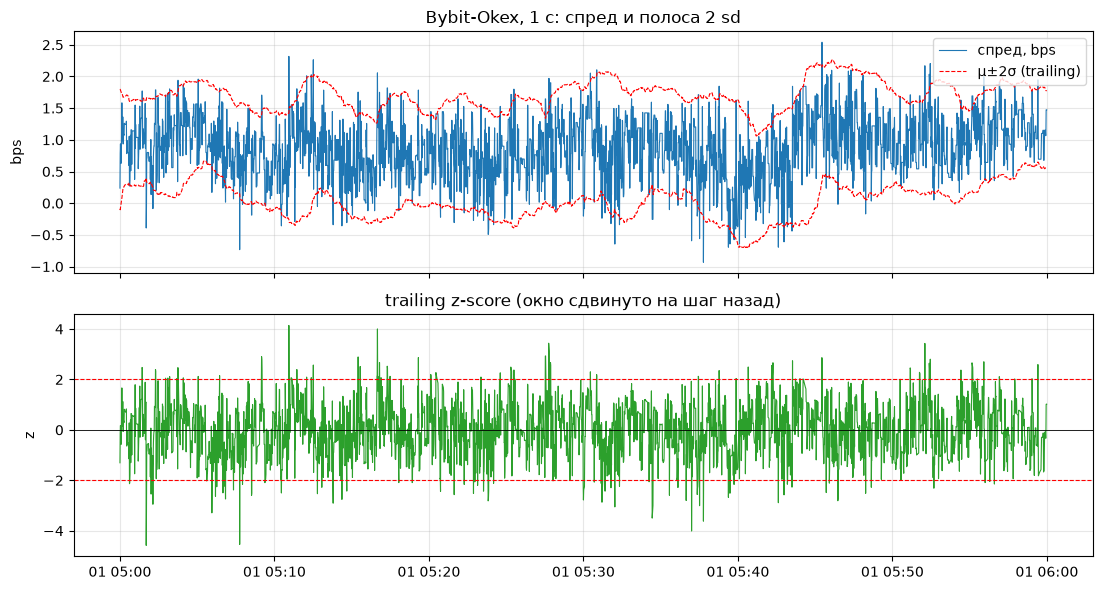

In [9]:
# Картинка на коротком окне: спред и границы полосы — чтобы видеть, что триггерится, а что нет.
s, z, W = ZSTORE['1 s']
mu = s.rolling(W).mean().shift(1); sd = s.rolling(W).std().shift(1)
seg = slice(7200, 7200 + 3600)          # окно в один час, начиная со второго часа
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(s.index[seg], s.values[seg], lw=0.8, label='спред, bps')
ax[0].plot(s.index[seg], (mu + 2 * sd).values[seg], 'r--', lw=0.8, label='μ±2σ (trailing)')
ax[0].plot(s.index[seg], (mu - 2 * sd).values[seg], 'r--', lw=0.8)
ax[0].set_ylabel('bps'); ax[0].legend(loc='upper right'); ax[0].set_title('Bybit-Okex, 1 с: спред и полоса 2 sd')
ax[1].plot(s.index[seg], z[seg], lw=0.8, color='tab:green'); ax[1].axhline(2, color='r', ls='--', lw=0.8)
ax[1].axhline(-2, color='r', ls='--', lw=0.8); ax[1].axhline(0, color='k', lw=0.6)
ax[1].set_ylabel('z'); ax[1].set_title('trailing z-score (окно сдвинуто на шаг назад)')
plt.tight_layout(); plt.show()


### Prefix-тест

Обязательная проверка отсутствия look-ahead: если усечь вход в момент $t$, значение $z(t)$ не должно измениться — ведь оно зависит только от прошлого. Пересчитываем сигнал на усечённых до $t$ рядах в нескольких точках и сравниваем с полным рядом.

In [10]:
passed = True
for label in GRIDS:
    s, z, W = ZSTORE[label]
    for frac in (0.03, 0.2, 0.5, 0.85):        # точки усечения — доля длины ряда
        t = int(frac * len(s))
        st = s.iloc[:t + 1]
        mut = st.rolling(W).mean().shift(1); sdt = st.rolling(W).std().shift(1)
        zt = ((st - mut) / sdt).values[-1]
        if not np.allclose(zt, z[t], equal_nan=True):
            passed = False
            print(f'{label}: РАСХОЖДЕНИЕ при t={t}: {zt} vs {z[t]}')
print('prefix-тест пройден:', passed)


prefix-тест пройден: True


Результат sweep — честный null, и он ожидаем. Gross на сделку положителен и растёт с полосой: от $+0.77$ bps при $k=0.5$ до $+1.61$ bps при $k=3.0$ на 1-с сетке (та же картина на 5 с). Знак и рост логичны: чем шире полоса, тем дальше от среднего мы входим и тем больше ожидаемый откат. Но gross $1$–$1.6$ bps — это на порядок меньше round-trip $21$ bps, поэтому **net на сделку лежит в диапазоне $-19.4$…$-20.2$ bps и не пересекает ноль ни при одной полосе** от $0.5$ до $3.0$ sd. На 1-с сетке при $k=3.0$ это $1020$ сделок и суммарно около $-19\,800$ bps; на 5-с сетке сделок меньше ($263$ при $k=3.0$), но per-trade картина та же. Частота выигрышных сделок по gross около $0.999$ (до издержек) не должна вводить в заблуждение: выигрывает почти каждая сделка, но типичный gross-выигрыш в десятки раз меньше round-trip — классическая форма null-результата, где частота успеха и прибыльность расходятся.

Две проверки, что этот null — не артефакт настройки. Первая, **по окну**: при $W = 10/20/40$ half-life net на сделку остаётся в узкой полосе $-19$…$-20$ bps при любой базе (gross чуть растёт с окном, но до нуля далеко), то есть вывод от гиперпараметра окна не зависит. Вторая, **по ставке**: даже если понизить taker-комиссию вдвое (VIP/ребейты, $10.5$ bps за круг), net всё ещё $-8.9$…$-9.7$ bps; чтобы стратегия вышла в ноль при $k=3.0$, ставку надо срезать примерно в $13$ раз, а при $k=0.5$ — в $27$ раз. Ни одна реалистичная скидка до этого не доходит, поэтому null устойчив и к окну, и к ставке.

## Пункт 3 — hindsight: centred mean и призрачный P&L

Пусть теперь среднее оценивается окном **вокруг** точки, а не до неё. Формально это `rolling(..., center=True)`: среднее в момент $t$ подтягивается будущими значениями, и сигнал начинает «знать», куда спред пойдёт. Это уже не стратегия, а подглядывание, и его надо показать, чтобы увидеть цену обмана. Прогоняем ту же механику (полоса $1$ sd) на реальном ряду с тремя вариантами центра: trailing (честный), centred (смотрит в будущее) и whole-sample (среднее всего ряда, тоже недоступно в реальном времени). Плюс воспроизводим механизм слайда 16 на симуляции OU: trailing против centred против oracle (истинное среднее).

In [11]:
s, z, W = ZSTORE['1 s']                      # Bybit-Okex, 1 с
def total_pnl(s, z):
    x = s.values; pos = positions_from_z(z, 1.0)
    return float((pos[:-1] * np.diff(x)).sum())

sd_tr = s.rolling(W).std().shift(1)
variants = {
    'trailing (честно)':  s.rolling(W).mean().shift(1),
    'centred (подглядывает)': s.rolling(W, center=True).mean(),
    'whole-sample (недоступно)': pd.Series(s.mean(), index=s.index),
}
real_rows = []
for name, m in variants.items():
    tot = total_pnl(s, ((s - m) / sd_tr).values)
    real_rows.append({'центр': name, 'P&L всего, bps': round(tot, 0),
                      'на 1000 тактов, bps': round(tot / len(s) * 1000, 3)})
print('=== hindsight на реальном спреде Bybit-Okex (band = 1 sd) ===')
display(pd.DataFrame(real_rows))
base = real_rows[0]['P&L всего, bps']
print(f'centred льстит на {100 * (real_rows[1]["P&L всего, bps"] / base - 1):+.1f} % '
      f'против честного trailing')


=== hindsight на реальном спреде Bybit-Okex (band = 1 sd) ===


,центр,"P&L всего, bps","на 1000 тактов, bps"
0,trailing (честно),12442.0,72.064
1,centred (подглядывает),13564.0,78.559
2,whole-sample (недоступно),7673.0,44.442


centred льстит на +9.0 % против честного trailing


In [12]:
print('=== механизм слайда 16 на симуляции OU: φ=0.95, sd=1, T=1000, окно 50 ===')
def total_pnl_series(x, z):
    pos = positions_from_z(z, 1.0)
    return float((pos[:-1] * np.diff(x)).sum())

T_s, phi_s, sd_s, W_s = 1000, 0.95, 1.0, 50
sim = {'trailing': [], 'centred': [], 'oracle': []}
for _ in range(300):
    u = sim_ar1(phi_s, 0.0, sd_s * np.sqrt(1 - phi_s**2), T_s, RNG, burn=200)
    m = pd.Series(u); sdt = m.rolling(W_s).std().shift(1)
    z_tr = ((m - m.rolling(W_s).mean().shift(1)) / sdt).values
    z_ct = ((m - m.rolling(W_s, center=True).mean()) / sdt).values
    z_or = ((m - 0.0) / sdt).values
    sim['trailing'].append(total_pnl_series(u, z_tr))
    sim['centred'].append(total_pnl_series(u, z_ct))
    sim['oracle'].append(total_pnl_series(u, z_or))
sim_rows = [{'вариант': k, 'P&L на 1000 шагов, bps': round(np.mean(v) / T_s * 1000, 1),
             'к trailing, %': round(100 * (np.mean(v) / np.mean(sim['trailing']) - 1), 1)}
            for k, v in sim.items()]
display(pd.DataFrame(sim_rows))
print(f'слайд 16 даёт +16–17 % для centred и oracle при своём T; здесь centred даёт '
      f'{100 * (np.mean(sim["centred"]) / np.mean(sim["trailing"]) - 1):+.0f} % — '
      f'знак и природа обмана те же, величина зависит от W, φ и T')
print('centred здесь обгоняет oracle: centred адаптирует среднее к локальным флуктуациям ряда,')
print('тогда как oracle использует глобальное μ; на коротком окне и конкретном seed')
print('локальная адаптация даёт больший выигрыш (на слайде 16 при своём T они почти равны)')

=== механизм слайда 16 на симуляции OU: φ=0.95, sd=1, T=1000, окно 50 ===


,вариант,"P&L на 1000 шагов, bps","к trailing, %"
0,trailing,25.1,0.0
1,centred,50.4,101.1
2,oracle,34.1,36.1


слайд 16 даёт +16–17 % для centred и oracle при своём T; здесь centred даёт +101 % — знак и природа обмана те же, величина зависит от W, φ и T
centred здесь обгоняет oracle: centred адаптирует среднее к локальным флуктуациям ряда,
тогда как oracle использует глобальное μ; на коротком окне и конкретном seed
локальная адаптация даёт больший выигрыш (на слайде 16 при своём T они почти равны)


Призрачный P&L есть, и он не маленький: на реальном спреде centred-центр добавляет около $+9\ \%$ к честному P&L, а в симуляции на короткой выборке — десятки процентов. Важен не точный процент, а источник: центр, который видит будущее, размещает среднее там, куда спред как раз и придёт, поэтому сделки закрываются у идеального уровня. Именно это и ловит prefix-тест из пункта 2: для centred-среднего усечение входа в $t$ **изменит** $z(t)$ (будущее уедет), а для trailing — нет. Мы показали величину обмана, но в качестве рабочей стратегии держим только trailing-вариант из пункта 2; centred и whole-sample здесь — исключительно демонстрация того, как льстит бэктесту подглядывание.

## Пункт 4 — сравнение equilibrium sd с издержками, в единицах sd

Теперь главный расчёт дня, и он помещается в одну строку. Round-trip издержки в единицах equilibrium sd:

$$c = \frac{\text{стоимость круговой сделки}}{\sigma_{eq}}.$$

Если $c$ заметно больше единицы, то чтобы стратегия вышла в ноль, отклонение должно быть больше нескольких equilibrium sd, а такие события редки — и выигрыш от них не покрывает издержку. Порог в единицах sd для полосы $k$ оцениваем как $k \gtrsim c$ минус типичный overshoot (спред заходит за полосу и разворачивается), поэтому break-even band — грубо порядка $c$ sd.

In [13]:
cost_rows = []
for label, (rule, dt) in GRIDS.items():
    for a, b in PAIRS:
        _, r = OU[(label, a, b)]
        c = roundtrip_cost_bps(a, b) / r['eq']
        cost_rows.append({'каденс': label, 'пара': f'{a}-{b}', 'σ_eq, bps': round(r['eq'], 3),
                          'round-trip, bps': roundtrip_cost_bps(a, b), 'c, sd': round(c, 1),
                          'break-even band ≈ c, sd': round(c, 1)})
print('=== цена круговой сделки в единицах equilibrium sd ===')
display(pd.DataFrame(cost_rows))
eq_ex = OU[('1 s', 'Bybit', 'Okex')][1]['eq']
print(f'Bybit-Okex: σ_eq = {eq_ex:.3f} bps, c = {roundtrip_cost_bps("Bybit","Okex")/eq_ex:.1f} sd —')
print('break-even band лежит далеко за пределами разумного диапазона 0.5–3 sd из пункта 2.')


=== цена круговой сделки в единицах equilibrium sd ===


,каденс,пара,"σ_eq, bps","round-trip, bps","c, sd","break-even band ≈ c, sd"
0,1 s,Bybit-Okex,0.829,21.0,25.3,25.3
1,1 s,Bybit-Binance,0.844,21.0,24.9,24.9
2,1 s,Okex-Binance,0.839,20.0,23.8,23.8
3,5 s,Bybit-Okex,0.828,21.0,25.4,25.4
4,5 s,Bybit-Binance,0.847,21.0,24.8,24.8
5,5 s,Okex-Binance,0.840,20.0,23.8,23.8


Bybit-Okex: σ_eq = 0.829 bps, c = 25.3 sd —
break-even band лежит далеко за пределами разумного диапазона 0.5–3 sd из пункта 2.


Числа не оставляют места для интерпретации. Equilibrium sd — около $0.83$ bps, round-trip — $20$–$21$ bps, то есть $c \approx 24$–$25$ equilibrium sd: отклонение должно было бы составить около двадцати пяти стандартных равновесных отклонений, чтобы просто окупить вход-выход. Реалистичные band $0.5$–$3$ sd проигрывают с огромным запасом, и это не артефакт конкретной полосы, а свойство масштаба: амплитуда возврата на два порядка меньше цены ошибки. Отсюда и вывод пункта 2 — null. Оговорка одна: издержки взяты по **base-tier taker** с публичных тарифов; у маркет-мейкера с ребейтами они падают, и тогда $c$ уменьшается. Чтобы band-стратегия на этом спреде окупилась, taker-издержку нужно снизить примерно в двадцать раз — этого публичная ликвидность не даёт (в пункте 2 мы это же показали на $\times 0.5$ ставки: net всё ещё около $-9$ bps), поэтому вывод «ни одна реалистичная полоса не выживает» держится с запасом, а не впритык.

## Пункт 5 — динамический hedge ratio: rolling OLS против Kalman

Ловушка этого пункта в том, что **адаптивный hedge ratio может поглотить реверсию**. Проверяем это на симулированной cross-asset паре, потому что у same-asset cross-venue спреда hedge ratio зафиксирован ($\beta = 1$), а нам нужен настоящий динамический $\beta$. Дизайн слайда 29: $T = 6000$; $x$ — случайное блуждание с шагом 1 плюс 100; истинный $\beta = 1.5 + \text{RW}(0.002)$ плюс скачок $+0.4$ на середине; $\alpha = 2$; спред $u$ — AR(1) с $\phi = 0.95$ и sd $1$; $y = \alpha + \beta x + u$. Оцениваем $\beta$ двумя способами: rolling OLS по окнам $200$ и $1000$ (строго прошлое, тот же `rolling_beta_alpha`, что на дне 6) и двумерным фильтром Калмана на состояние $[\alpha, \beta]$ с наблюдением $y = \alpha + \beta x + \varepsilon$, $\varepsilon \sim N(0, R)$, $Q = \delta I$, $R = 1$, $P_0 = 10I$. Помимо ошибки $\beta$, смотрим на свойства **реализованного спреда** $e_t = y_t - \hat\alpha - \hat\beta x_t$: его sd, hedge-error sd и лаг-1 автокорреляцию. Именно последние три показывают, осталась ли в спреде реверсия. Метрики считаем после начальной приработки фильтра ($t \ge 1000$), то есть на ряду, который включает и медленный drift $\beta$, и скачок в середине — именно на переходе методы расходятся сильнее всего, и именно это показывает слайд. Ниже мы отдельно проверяем и чистый steady-state после скачка.

In [14]:
def simulate_pair(rng, T=6000):
    x = np.cumsum(rng.normal(0, 1, T)) + 100.0
    beta = 1.5 + np.cumsum(rng.normal(0, 0.002, T)); beta[T // 2:] += 0.4
    phi, sd = 0.95, 1.0
    u = sim_ar1(phi, 0.0, sd * np.sqrt(1 - phi**2), T, rng, burn=300)
    return x, 2.0 + beta * x + u, beta, u

def rolling_beta_alpha(y, x, W):
    """β, α по окну [t-W, t-1], применённые к t (point-in-time)."""
    ys, xs = pd.Series(y), pd.Series(x)
    Sy, Sx = ys.rolling(W).sum(), xs.rolling(W).sum()
    Sxx, Sxy = (xs * xs).rolling(W).sum(), (xs * ys).rolling(W).sum()
    den = W * Sxx - Sx * Sx
    b = (W * Sxy - Sx * Sy) / den
    a = (Sy - b * Sx) / W
    return a.shift(1).values, b.shift(1).values

def kalman_beta(y, x, delta, R=1.0, P0=10.0):
    """2-мерный Калман [α, β]: random walk с ковариацией Q=δ·I, H_t=[1, x_t].
    a_hat/b_hat — прогноз (t|t-1); innovation e_t = y_t - H·θ(t|t-1) и S_t считаются до наблюдения y_t."""
    T = len(y); th = np.zeros((T, 2)); a_hat = np.zeros(T); b_hat = np.zeros(T)
    P = P0 * np.eye(2); Q = delta * np.eye(2)
    for t in range(T):
        H = np.array([1.0, x[t]])
        th_p = th[t - 1] if t > 0 else np.zeros(2)     # прогноз: F = I
        P_p = P + Q
        a_hat[t], b_hat[t] = th_p                       # отдаём прогноз (point-in-time)
        e = y[t] - H @ th_p                             # innovation
        S = H @ P_p @ H + R                             # S_t — до наблюдения y_t
        K = P_p @ H / S
        th[t] = th_p + K * e
        P = P_p - np.outer(K, H @ P_p)                  # = (I − K H) P_p
    TEST_COUNTER['Kalman'] += 1                         # считаем прогоны фильтра, не внутренние шаги
    return a_hat, b_hat

def spread_metrics(a_hat, b_hat, x, y, beta, t_lo=1000, t_hi=None):
    idx = np.arange(len(y)); ok = np.isfinite(a_hat) & np.isfinite(b_hat) & (idx >= t_lo)
    if t_hi is not None:
        ok &= idx < t_hi
    b, a, xx, yy, bb = b_hat[ok], a_hat[ok], x[ok], y[ok], beta[ok]
    e = yy - a - b * xx; db = b - bb
    return dict(beta_rmse=float(np.sqrt((db**2).mean())), hedge_sd=float(db.std(ddof=1)),
                spread_sd=float(e.std(ddof=1)), acf1=float(np.corrcoef(e[:-1], e[1:])[0, 1]))

RNG_SIM = np.random.default_rng(42)      # отдельный поток: результат не должен зависеть от расхода RNG выше
X, Y, BETA, U = simulate_pair(RNG_SIM)
print(f'истина: β в [{BETA.min():.3f}, {BETA.max():.3f}], спред sd = {U.std(ddof=1):.3f}, '
      f'лаг-1 acf = {np.corrcoef(U[:-1], U[1:])[0, 1]:.3f}')

beta_rows = []
paths = {}
for W in (200, 1000):
    a_hat, b_hat = rolling_beta_alpha(Y, X, W)
    beta_rows.append({'оценка': f'rolling OLS, W={W}', **{k: round(v, 4) for k, v in
                     spread_metrics(a_hat, b_hat, X, Y, BETA).items()}})
    paths[f'OLS {W}'] = b_hat
    TEST_COUNTER['rolling OLS'] += 1
for delta in (1e-7, 1e-5, 1e-3):
    a_hat, b_hat = kalman_beta(Y, X, delta)
    beta_rows.append({'оценка': f'Kalman, Q/R={delta:g}', **{k: round(v, 4) for k, v in
                     spread_metrics(a_hat, b_hat, X, Y, BETA).items()}})
    paths[f'KF {delta:g}'] = b_hat
print('=== точность β и свойства реализованного спреда (t ≥ 1000: включает drift и скачок β) ===')
display(pd.DataFrame(beta_rows))

# Контроль: те же метрики в чистом steady-state после скачка (t ≥ 4500)
steady_rows = []
for W in (200, 1000):
    a_hat, b_hat = rolling_beta_alpha(Y, X, W)
    steady_rows.append({'оценка': f'rolling OLS, W={W}', **{k: round(v, 4) for k, v in
                        spread_metrics(a_hat, b_hat, X, Y, BETA, t_lo=4500).items()}})
for delta in (1e-7, 1e-5, 1e-3):
    a_hat, b_hat = kalman_beta(Y, X, delta)
    steady_rows.append({'оценка': f'Kalman, Q/R={delta:g}', **{k: round(v, 4) for k, v in
                        spread_metrics(a_hat, b_hat, X, Y, BETA, t_lo=4500).items()}})
print('=== контроль: метрики в steady-state после скачка (t ≥ 4500) ===')
display(pd.DataFrame(steady_rows))

истина: β в [1.430, 1.915], спред sd = 1.019, лаг-1 acf = 0.952


=== точность β и свойства реализованного спреда (t ≥ 1000: включает drift и скачок β) ===


,оценка,beta_rmse,hedge_sd,spread_sd,acf1
0,"rolling OLS, W=200",0.0868,0.0849,1.2689,0.9586
1,"rolling OLS, W=1000",0.0901,0.0874,2.1524,0.9854
2,"Kalman, Q/R=1e-07",0.0588,0.0576,1.3964,0.9667
3,"Kalman, Q/R=1e-05",0.0485,0.0485,0.7738,0.8881
4,"Kalman, Q/R=0.001",0.0767,0.0767,0.4372,0.5299


=== контроль: метрики в steady-state после скачка (t ≥ 4500) ===


,оценка,beta_rmse,hedge_sd,spread_sd,acf1
0,"rolling OLS, W=200",0.0616,0.0613,1.1413,0.9607
1,"rolling OLS, W=1000",0.0443,0.0366,1.2011,0.9647
2,"Kalman, Q/R=1e-07",0.0357,0.0259,1.1024,0.9587
3,"Kalman, Q/R=1e-05",0.0587,0.0587,0.7296,0.9013
4,"Kalman, Q/R=0.001",0.1058,0.1057,0.4330,0.6345


Таблица говорит всё, что нужно. Rolling OLS ведёт себя так, как и предупреждал слайд: ошибка $\beta$ RMSE порядка $0.09$, но реализованный спред выходит sd $\approx 1.3$ при окне $200$ и $\approx 2.2$ при окне $1000$ — против истинных $\approx 1.0$. Удлинение окна ошибку $\beta$ почти не меняет (длинное окно так же плохо успевает за скачком $\beta$), зато раздувает спред: осевший из-за медленной адаптации сдвиг целиком уходит в остаток. Kalman с очень малым $Q/R = 10^{-7}$ почти не адаптируется и ведёт себя как OLS: ошибка $\beta \approx 0.059$, спред раздут (sd $\approx 1.40$), автокорреляция сохраняется ($0.97$). По мере роста $Q/R$ фильтр начинает гнаться за $\beta$: ошибка $\beta$ проходит минимум около $Q/R = 10^{-5}$ (RMSE $\approx 0.049$), а при дальнейшем росте снова растёт — теперь фильтр принимает за сдвиг $\beta$ собственный шум спреда. И вот плата, которая не зависит от мелких деталей: sd реализованного спреда монотонно падает, а лаг-1 автокорреляция рушится. На нашем прогоне $Q/R = 10^{-7} \to 10^{-5} \to 10^{-3}$ даёт sd спреда $1.40 \to 0.77 \to 0.44$ и acf $0.97 \to 0.89 \to 0.53$. То есть быстрый Kalman делает спред **меньше** (и это выглядит как успех по дисперсии спреда) и **менее реверсивным** (а это уже катастрофа для торговли на возврате): адаптивный $\beta$ поглощает ту самую реверсию, которую мы собираемся торговать.

Ради честности — вторая таблица (steady-state, $t \ge 4500$ — только после скачка): там раздувание спреда у rolling OLS почти исчезает (sd $1.14$/$1.20$ против истины $1.0$), а длинное окно даже точнее короткого, потому что после скачка $\beta$ постоянен и окно успевает за ним. Значит «раздутость» спреда у rolling OLS — это **цена переходного процесса** (drift и скачок $\beta$), а не вечное свойство метода. Для Kalman же вывод не меняется ни в одном окне: рост $Q/R$ по-прежнему схлопывает sd ($1.10 \to 0.73 \to 0.43$) и рушит автокорреляцию ($0.96 \to 0.90 \to 0.63$). Абсолютные числа чувствительны к реализации: это один генератор и один seed, при другом случайном блуждании уровень ошибок сдвинется (мы видели, как неудачная траектория $x$ раздувает OLS-ошибку в разы). Знак и монотонность trade-off при этом устойчивы, и именно их надо запомнить.

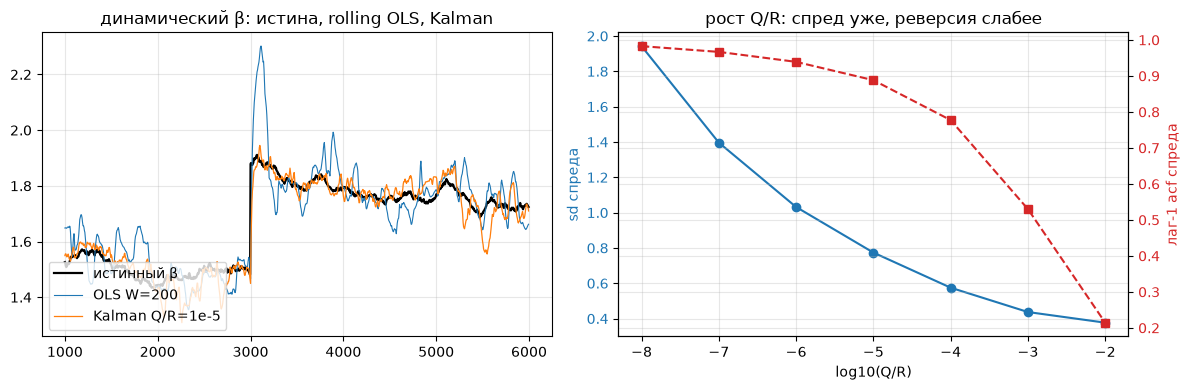

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sub = slice(1000, 6000, 5)
ax[0].plot(np.arange(1000, 6000, 5), BETA[sub], 'k', lw=1.6, label='истинный β')
ax[0].plot(np.arange(1000, 6000, 5), paths['OLS 200'][sub], lw=0.8, label='OLS W=200')
ax[0].plot(np.arange(1000, 6000, 5), paths['KF 1e-05'][sub], lw=0.9, label='Kalman Q/R=1e-5')
ax[0].set_title('динамический β: истина, rolling OLS, Kalman'); ax[0].legend(loc='lower left')
qs = np.array([1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2])
sdv = []; acv = []
for d in qs:
    aa, bb = kalman_beta(Y, X, d); m = spread_metrics(aa, bb, X, Y, BETA)
    sdv.append(m['spread_sd']); acv.append(m['acf1'])
ax2 = ax[1]; ax2.plot(np.log10(qs), sdv, 'o-', color='tab:blue', label='sd спреда')
ax2.set_xlabel('log10(Q/R)'); ax2.set_ylabel('sd спреда', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax3 = ax2.twinx(); ax3.plot(np.log10(qs), acv, 's--', color='tab:red')
ax3.set_ylabel('лаг-1 acf спреда', color='tab:red'); ax3.tick_params(axis='y', labelcolor='tab:red')
ax2.set_title('рост Q/R: спред уже, реверсия слабее'); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()


In [16]:
# Устойчивость trade-off Q/R к seed: три отдельных генератора, тот же Kalman, что выше.
# Проверяем не абсолютные уровни, а знак и монотонность: sd спреда и acf1 должны падать при Q/R -> больше.
seed_rows = []
for seed in (11, 42, 77):
    xs, ys, bs, _ = simulate_pair(np.random.default_rng(seed))
    ms = {d: spread_metrics(*kalman_beta(ys, xs, d), xs, ys, bs) for d in (1e-7, 1e-5, 1e-3)}
    sd_seq = [ms[d]['spread_sd'] for d in (1e-7, 1e-5, 1e-3)]
    ac_seq = [ms[d]['acf1'] for d in (1e-7, 1e-5, 1e-3)]
    seed_rows.append({'seed': seed,
                      'sd спреда (Q/R 1e-7→1e-5→1e-3)': ' → '.join(f'{v:.2f}' for v in sd_seq),
                      'лаг-1 acf (Q/R 1e-7→1e-5→1e-3)': ' → '.join(f'{v:.2f}' for v in ac_seq),
                      'монотонно убывают': bool(all(np.diff(sd_seq) < 0) and all(np.diff(ac_seq) < 0))})
print('=== контроль: монотонность trade-off Q/R на трёх seed ===')
display(pd.DataFrame(seed_rows))


=== контроль: монотонность trade-off Q/R на трёх seed ===


,seed,sd спреда (Q/R 1e-7→1e-5→1e-3),лаг-1 acf (Q/R 1e-7→1e-5→1e-3),монотонно убывают
0,11,3.16 → 1.27 → 1.00,0.95 → 0.61 → 0.04,True
1,42,1.40 → 0.77 → 0.44,0.97 → 0.89 → 0.53,True
2,77,2.84 → 1.12 → 0.85,0.95 → 0.65 → 0.05,True


Практический вопрос — как выбирать $Q/R$, и таблица отвечает: **не по ошибке $\beta$**. Минимум $\beta$-RMSE и минимум автокорреляции спреда достигаются при разных $Q/R$, и если тюнить только на $\beta$, легко приехать в режим, где спред стал белым шумом, а торговать на возврате нечего. Правильный критерий — свойства спреда: сохранить его размер, реверсивность и half-life. Оговорка к симуляции: абсолютные уровни зависят от реализации — основная таблица это один генератор и один seed. Но монотонный trade-off ($Q/R \uparrow \Rightarrow$ спред уже и менее реверсивен) проверяем прямо в ноутбуке: контрольный расчёт выше прогоняет Kalman на трёх seed (11, 42, 77), и на всех трёх sd и acf1 спадают монотонно по всему диапазону $Q/R$.

## Пункт 6 — funding: как разница ставок сдвигала бы цель

Здесь вычислений нет, и это надо сказать прямо. В файле — только L2-перпетуалы; нет funding-платежей, нет spot-ноги, нет датированных контрактов. Поэтому построить **funding-adjusted спред** на этих данных нельзя: чтобы его посчитать, нужны истории ставок funding по каждой площадке и, в идеале, spot-цена того же актива, которой в выдаче нет. Влияние funding на задачу можно описать точно и без этого. У перпетуала держатель платит или получает funding каждые несколько часов; эти платежи не входят в mid-цену, но входят в экономику позиции. Если две площадки имеют разные ставки, то cross-venue позиция (лонг на $A$, шорт на $B$) несёт, кроме спреда цены $P_A - P_B$, ещё и разницу funding: положительную, если ставка на шортируемой ноге ниже. Экономический уровень, к которому возвращается доходность позиции, — это не $\mu$ спреда цены, а $\mu - \mathbb{E}[\text{funding}_A - \text{funding}_B]$ в пересчёте на единицу времени: разница ставок сдвигает **цель** $\alpha$ (свободный член) в OU-модели, оставляя скорость возврата $\kappa$ и амплитуду $\sigma_{eq}$ примерно неизменными, потому что funding меняется медленно по сравнению с half-life в секунды. Практически это означает, что funding не создаёт торгового сигнала на нашем горизонте, но добавляет к издержкам медленно накапливающийся член — и если бы мы считали net-доходность всерьёз, его надо было бы прибавить к round-trip. Порядок его малости можно прикинуть качественно: funding начисляется раз в цикл расчёта (стандарт перпетуалов — 8 часов, часть бирж считает чаще, то есть от часа до восьми часов): это базисные пункты за цикл, и на сделке длиной в секунды он исчезающе мал по сравнению с $21$ bps taker-издержек, но за дни удержания становится заметным. Точное влияние мы здесь не измеряем: для этого нет данных, и лучше сказать это честно, чем подставить выдуманное число.

## Выводы и ограничения

Собираем итог по шести пунктам.

**1. OU-фит.** Cross-venue спред BTC — OU с half-life $5.8$–$6.6$ с на 1-с сетке и $15.7$–$19.4$ с на 5-с сетке (в тактах — $3.1$–$3.9$); equilibrium sd устойчиво $0.83$–$0.85$ bps, уровни $\mu$ — $0.02$–$0.19$ bps. Half-life воспроизводится при смене каденса с точностью до дискретизации, а не артефакт одного шага.

**2. Bootstrap.** На наших длинных выборках ($T \approx 1.7\!\cdot\!10^5$) half-life измерена почти без смещения: интервал 5–95 % шириной порядка $\pm 2\ \%$, смещение — доли процента. Опасное смещение авторегрессии ($-(1+3\phi)/T$) — свойство коротких выборок: контроль при $T = 250$ даёт half-life заниженной более чем вдвое (медиана $27$ против истинных $69$).

**3. Band-стратегия.** Gross на сделку $+0.8$…$+1.7$ bps растёт с полосой, но net после round-trip $20$–$21$ bps остаётся в диапазоне $-19$…$-20$ bps при любой полосе $0.5$–$3$ sd. Это честный **null**: частота выигрышных сделок по gross около $0.999$ (до издержек), но типичный выигрыш в десятки раз меньше издержек. Null не зависит ни от окна ($10/20/40$ half-life), ни от ставки (при $\times 0.5$ всё ещё $\approx -9$ bps).

**4. Hindsight.** Centred mean льстит бэктесту (на реальном ряду $+9\ \%$, в симуляции — десятки процентов к честному trailing-варианту); prefix-тест именно это и отсекает, и он пройден для рабочей стратегии.

**5. Cost в единицах sd.** $c = $ round-trip $/ \sigma_{eq} \approx 24$–$25$ sd. Break-even band лежит далеко за пределами $3$ sd, поэтому вывод пункта 2 устойчив, а не зависит от выбора полосы.

**6. Динамический $\beta$.** Ошибка $\beta$ у Kalman минимальна при средних $Q/R$ (RMSE $\approx 0.049$ против $\approx 0.087$ у rolling OLS), но рост $Q/R$ разрушает реверсию спреда: sd спреда $1.40 \to 0.44$, лаг-1 acf $0.97 \to 0.53$. Тюнить адаптацию надо по свойствам спреда (размер, half-life, автокорреляция), а не по $\beta$-ошибке.

**7. Funding.** На L2-данных без ставок и spot-ноги funding-adjusted спред не строится; качественно разница funding сдвигает цель $\alpha$, не трогая $\kappa$ и $\sigma_{eq}$, и на секундном горизонте исчезающе мала на фоне taker-издержек.

**Ограничения.** Данных два дня, поэтому мы говорим о микроструктурном горизонте и не переносим выводы на дневной. Издержки взяты по base-tier taker с публичных тарифов (сверены 2026-10-04); у маркет-мейкера картина мягче, и это единственный канал, который мог бы оживить band-стратегию. Funding не измерен — нет данных. Симуляция динамического $\beta$ — один генератор: уровни ошибок зависят от seed, но не знак эффекта. И, наконец, кросс-venue спред стационарен **по смыслу инструмента** (одна бумага на двух площадках), так что сам факт возврата — не открытие: интересен его измеримый масштаб, и он оказался слишком мал по сравнению с ценой сделки.

In [17]:
print('=== сводка дня 7 ===')
print('данные     : 3 биржи, BTC, 48 ч; cross-venue спред β=1 в bps; сетки 1 с и 5 с')
print('OU         : half-life 5.8-6.6 с (1 с) и 15.7-19.4 с (5 с); σ_eq ≈ 0.83 bps; μ 0.02-0.19 bps')
print('bootstrap  : на наших T смещение half-life доли процента, интервал ±2 %; опасное смещение — на коротких T (T=250 занижена >2x, механизм слайда 11)')
print('band sweep : gross/сделку +0.8..+1.7 bps; net/сделку -19..-20 bps при всех полосах 0.5-3 sd -> null')
print('null устойчив: по окну 10/20/40 hl net тот же; при ×0.5 ставки net всё ещё ~-9 bps (ставка ×13..27 до нуля)')
print('hindsight  : centred mean льстит (+9 % на реальном ряду); prefix-тест пройден для trailing')
print('цена сделки: c ≈ 24-25 σ_eq; break-even band >> 3 sd')
print('dynamic β  : rolling OLS(200/1000) β RMSE ~0.09, спред раздут (sd 1.3/2.2 vs truth 1.0);')
print('             Kalman Q/R 1e-7..1e-3: β RMSE 0.049-0.077, sd спреда 1.40->0.44,')
print('             лаг-1 acf 0.97->0.53 — адаптация убивает реверсию (держится и в steady-state; монотонность на 3 seed)')
print(f'испытаний  : ' + ', '.join(f'{k} = {v}' for k, v in TEST_COUNTER.items()))

=== сводка дня 7 ===
данные     : 3 биржи, BTC, 48 ч; cross-venue спред β=1 в bps; сетки 1 с и 5 с
OU         : half-life 5.8-6.6 с (1 с) и 15.7-19.4 с (5 с); σ_eq ≈ 0.83 bps; μ 0.02-0.19 bps
bootstrap  : на наших T смещение half-life доли процента, интервал ±2 %; опасное смещение — на коротких T (T=250 занижена >2x, механизм слайда 11)
band sweep : gross/сделку +0.8..+1.7 bps; net/сделку -19..-20 bps при всех полосах 0.5-3 sd -> null
null устойчив: по окну 10/20/40 hl net тот же; при ×0.5 ставки net всё ещё ~-9 bps (ставка ×13..27 до нуля)
hindsight  : centred mean льстит (+9 % на реальном ряду); prefix-тест пройден для trailing
цена сделки: c ≈ 24-25 σ_eq; break-even band >> 3 sd
dynamic β  : rolling OLS(200/1000) β RMSE ~0.09, спред раздут (sd 1.3/2.2 vs truth 1.0);
             Kalman Q/R 1e-7..1e-3: β RMSE 0.049-0.077, sd спреда 1.40->0.44,
             лаг-1 acf 0.97->0.53 — адаптация убивает реверсию (держится и в steady-state; монотонность на 3 seed)
испытаний  : AR(1)/OLS (фит